In [2]:
import numpy as np

class KMeansScratch:
    def __init__(self, k=3, max_iters=100, tol=1e-4):
        self.k = k
        self.max_iters = max_iters
        self.tol = tol

    def initialize_centroids(self, X):
        random_indices = np.random.choice(X.shape[0], self.k, replace=False)
        return X[random_indices]

    def compute_distances(self, X, centroids):
        distances = np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))
        return distances

    def assign_clusters(self, distances):
        return np.argmin(distances, axis=0)

    def update_centroids(self, X, labels):
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(self.k)])
        return new_centroids

    def fit(self, X):
        self.centroids = self.initialize_centroids(X)

        for _ in range(self.max_iters):
            distances = self.compute_distances(X, self.centroids)
            labels = self.assign_clusters(distances)

            new_centroids = self.update_centroids(X, labels)

            if np.all(np.abs(new_centroids - self.centroids) < self.tol):
                break

            self.centroids = new_centroids

        self.labels = labels
        return self

    def predict(self, X):
        distances = self.compute_distances(X, self.centroids)
        return self.assign_clusters(distances)

In [3]:
# Create sample dataset
np.random.seed(42)
X = np.vstack((
    np.random.randn(100, 2) + [2, 2],
    np.random.randn(100, 2) + [-2, -2],
    np.random.randn(100, 2) + [5, -5]
))

# Fit model
kmeans = KMeansScratch(k=3)
kmeans.fit(X)

print("Centroids:")
print(kmeans.centroids)

Centroids:
[[-1.87565834 -1.99498956]
 [ 1.85107547  2.03222737]
 [ 4.95496261 -5.12627268]]


In [4]:
def calculate_wcss(self, X):
    distances = self.compute_distances(X, self.centroids)
    closest_distances = np.min(distances, axis=0)
    return np.sum(closest_distances**2)

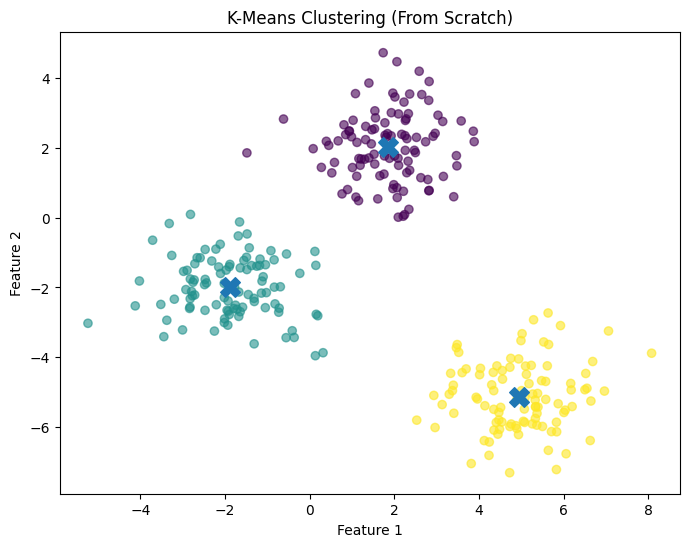

In [5]:
import matplotlib.pyplot as plt

def plot_clusters(X, labels, centroids):
    plt.figure(figsize=(8, 6))

    # Plot data points
    plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', alpha=0.6)

    # Plot centroids
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='X', s=200)

    plt.title("K-Means Clustering (From Scratch)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


# Fit model
kmeans = KMeansScratch(k=3)
kmeans.fit(X)

# Plot
plot_clusters(X, kmeans.labels, kmeans.centroids)